# P2PNet + MovingDroneCrowd++ — guided Colab workflow

This notebook automates repetitive and safety-critical work while keeping research choices
visible. It does **not** silently choose your initialization, crop strategy, checkpoint, or
test configuration.

## Recommended action order

1. **`inspect`** — confirm every resolved path and parameter; changes nothing.
2. **`smoke`** — test the currently selected crop/batch/patch configuration end to end.
3. **`benchmark`** — compare the technical cost of `512×1` and `256×4` using time and GPU
   memory. This does not establish which is more accurate.
4. **Choose** `CROP_SIZE` and `NUM_PATCHES` from the evidence and your research reasoning.
5. **`train`** — start the named run. Validation, logging, checkpoints and early stopping
   are automatic and visible.
6. Inspect the **training dashboard**. Use **`resume`** after a runtime reset if necessary.
7. **`evaluate`** on the complete validation split using the best checkpoint.
8. Tune the confidence threshold on validation by rerunning `evaluate` with new thresholds.
9. Freeze all choices, then explicitly unlock and evaluate the held-out test split.

After a fresh runtime, run setup sections 1–4. Sections 5–8 are optional diagnostics and
are skipped by default, including during **Run all**. The main guided workflow begins with
preflight in section 9. Persistent artifacts are kept
under `MyDrive/P2PNet_MDC`.


In [ ]:
# @title 0. Control panel — normally this is the only cell you edit
from pathlib import Path

# ---------- CURRENT ACTION ----------
ACTION = "inspect"  # @param ["inspect", "smoke", "benchmark", "train", "resume", "evaluate", "inference"]
# Leave this off for the guided workflow. It only unlocks the older sections 5–8.
RUN_OPTIONAL_SETUP_DIAGNOSTICS = False  # @param {type:"boolean"}

# ---------- REPOSITORY AND DATA ----------
REPO_URL = "https://github.com/gabrielxmit10/P2PNet_test1.git"  # @param {type:"string"}
REPO_REF = "main"  # @param {type:"string"}
REPO_DIR = Path("/content/P2PNet_MDC")

DRIVE_PROJECT = Path("/content/drive/MyDrive/P2PNet_MDC")
DATA_SOURCE = "archive"  # @param ["archive", "drive_folder", "already_staged"]
DATASET_ARCHIVE = DRIVE_PROJECT / "data/MovingDroneCrowd++.tar"
DRIVE_DATASET_FOLDER = DRIVE_PROJECT / "data/MovingDroneCrowd++"
DATASET_ROOT = Path("/content/data/MovingDroneCrowd++")

TRAIN_SPLIT = "train.txt"
VAL_SPLIT = "val.txt"
TEST_SPLIT = "test.txt"

# ---------- RUN AND WEIGHT SELECTION ----------
RUN_NAME = "p2pnet_mdc_run_001"  # @param {type:"string"}
RUN_DIR = DRIVE_PROJECT / "runs" / RUN_NAME
OFFICIAL_WEIGHTS = REPO_DIR / "weights/SHTechA.pth"

INITIALIZATION = "shanghaitech"  # @param ["shanghaitech", "imagenet", "scratch", "custom"]
CUSTOM_INITIALIZATION = ""  # @param {type:"string"}

RESUME_CHECKPOINT_CHOICE = "latest"  # @param ["latest", "best", "custom"]
CHECKPOINT_CHOICE = "best"  # @param ["best", "latest", "custom"]
CUSTOM_CHECKPOINT = ""  # @param {type:"string"}

# ---------- TRAINING CHOICES ----------
EPOCHS = 100  # @param {type:"integer"}
LR = 0.0001  # @param {type:"number"}
LR_BACKBONE = 0.00001  # @param {type:"number"}
WEIGHT_DECAY = 0.0001  # @param {type:"number"}
LR_DROP = 80  # @param {type:"integer"}
BATCH_SIZE = 1  # @param {type:"integer"}
CROP_SIZE = 512  # @param {type:"integer"}
NUM_PATCHES = 1  # @param {type:"integer"}
SCALE_MIN = 0.7  # @param {type:"number"}
SCALE_MAX = 1.3  # @param {type:"number"}
FLIP_PROBABILITY = 0.5  # @param {type:"number"}
MIN_CROP_POINTS = 1  # @param {type:"integer"}
TRAIN_FRAME_STRIDE = 1  # @param {type:"integer"}
PERIODIC_VAL_FRAME_STRIDE = 5  # @param {type:"integer"}
EVAL_FREQ = 5  # @param {type:"integer"}
SAVE_EVERY = 10  # @param {type:"integer"}
NUM_WORKERS = 2  # @param {type:"integer"}
SEED = 42  # @param {type:"integer"}
DETERMINISTIC = False  # @param {type:"boolean"}

# Automatic stopping: eligible only after MIN_EPOCHS, then counts validation checks.
EARLY_STOPPING = True  # @param {type:"boolean"}
EARLY_STOPPING_MIN_EPOCHS = 30  # @param {type:"integer"}
EARLY_STOPPING_PATIENCE = 4  # @param {type:"integer"}
EARLY_STOPPING_MIN_DELTA = 0.0  # @param {type:"number"}

# ---------- TECHNICAL BENCHMARK ----------
# Both candidates process roughly the same number of input pixels per optimizer update.
# The benchmark compares speed/memory only; you still choose the research configuration.
BENCHMARK_TRAIN_BATCHES = 20  # @param {type:"integer"}
BENCHMARK_VAL_FRAMES = 20  # @param {type:"integer"}
BENCHMARK_CONFIGS = [
    {"name": "context_512x1", "batch_size": 1, "crop_size": 512, "num_patches": 1},
    {"name": "coverage_256x4", "batch_size": 1, "crop_size": 256, "num_patches": 4},
]

# ---------- EVALUATION / INFERENCE ----------
DATA_SPLIT = "val"  # @param ["train", "val", "test"]
CONFIRM_FINAL_TEST = False  # @param {type:"boolean"}
THRESHOLD = 0.5  # @param {type:"number"}
TILE_SIZE = 1024  # @param {type:"integer"}
TILE_OVERLAP = 128  # @param {type:"integer"}
EVAL_FRAME_STRIDE = 1  # @param {type:"integer"}
MAX_EVAL_SAMPLES = 0  # @param {type:"integer"}
VISUALIZE_FIRST = 10  # @param {type:"integer"}

INFERENCE_INPUT = "/content/data/MovingDroneCrowd++/frames/scene_1/1"  # @param {type:"string"}
INFERENCE_RECURSIVE = False  # @param {type:"boolean"}
MAX_INFERENCE_IMAGES = 0  # @param {type:"integer"}
INFERENCE_MAX_SIZE = 0  # @param {type:"integer"}
SAVE_INFERENCE_VISUALIZATIONS = True  # @param {type:"boolean"}


## 1. Mount Drive and inspect the runtime

In [2]:
from google.colab import drive
import shutil, subprocess, sys, os, json, shlex, platform
drive.mount("/content/drive")
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Python:", sys.version)
subprocess.run(["nvidia-smi"], check=False)
usage = shutil.disk_usage("/content")
print(f"/content free: {usage.free / 2**30:.1f} GiB")

Mounted at /content/drive
Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
/content free: 188.3 GiB


## 2. Clone the modified repository and install lightweight dependencies
The Colab runtime cannot see ordinary files on your Windows disk. Push this modified repository first, then configure `REPO_URL` and `REPO_REF`.

In [3]:
if "YOUR_ACCOUNT" in REPO_URL or REPO_REF == "your-mdc-branch":
    raise ValueError("Set REPO_URL and REPO_REF in the configuration cell first.")
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    print("Reusing existing runtime checkout:", REPO_DIR)
subprocess.run(["git", "fetch", "origin", REPO_REF], cwd=REPO_DIR, check=True)
subprocess.run(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=REPO_DIR, check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-colab.txt"], cwd=REPO_DIR, check=True)
os.chdir(REPO_DIR)

def run(command):
    command = [str(value) for value in command]
    print("$", shlex.join(command))
    return subprocess.run(command, cwd=REPO_DIR, check=True)

import torch, torchvision
print("Commit:", subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_DIR, text=True).strip())
print("PyTorch:", torch.__version__, "torchvision:", torchvision.__version__, "CUDA:", torch.cuda.is_available())

Commit: 3207eaa8d27a655532f5fcfd625a22965f65d3e2
PyTorch: 2.11.0+cu128 torchvision: 0.26.0+cu128 CUDA: True


## 3. Stage MovingDroneCrowd++ on `/content`
`archive` is recommended. `drive_folder` works but performs many Drive file operations. `already_staged` only verifies an existing runtime path.

In [4]:
import tarfile
DATASET_ROOT.parent.mkdir(parents=True, exist_ok=True)
if DATASET_ROOT.exists():
    print("Dataset already staged:", DATASET_ROOT)
elif DATA_SOURCE == "archive":
    if not DATASET_ARCHIVE.is_file():
        raise FileNotFoundError(DATASET_ARCHIVE)
    archive_size = DATASET_ARCHIVE.stat().st_size
    free = shutil.disk_usage("/content").free
    if free < archive_size * 2.2:
        raise RuntimeError(f"Not enough /content disk: free={free/2**30:.1f} GiB, archive={archive_size/2**30:.1f} GiB")
    local_archive = Path("/content") / DATASET_ARCHIVE.name
    print("Copying archive to runtime disk...")
    shutil.copy2(DATASET_ARCHIVE, local_archive)
    print("Extracting...")
    with tarfile.open(local_archive) as archive:
        try:
            archive.extractall(DATASET_ROOT.parent, filter="data")
        except TypeError:
            archive.extractall(DATASET_ROOT.parent)
    local_archive.unlink()
elif DATA_SOURCE == "drive_folder":
    if not DRIVE_DATASET_FOLDER.is_dir():
        raise FileNotFoundError(DRIVE_DATASET_FOLDER)
    print("Copying dataset folder; this can be slow on Drive...")
    shutil.copytree(DRIVE_DATASET_FOLDER, DATASET_ROOT)
elif DATA_SOURCE != "already_staged":
    raise ValueError(f"Unknown DATA_SOURCE={DATA_SOURCE!r}")
if not (DATASET_ROOT / "frames").is_dir() or not (DATASET_ROOT / "annotations").is_dir():
    raise RuntimeError(f"Staged dataset layout is wrong: {DATASET_ROOT}")
print("Dataset ready:", DATASET_ROOT)

Copying archive to runtime disk...
Extracting...
Dataset ready: /content/data/MovingDroneCrowd++


## 4. Validate all split mappings and inspect one sample

In [5]:
run([sys.executable, "validate_mdc.py", "--data_root", DATASET_ROOT,
     "--output", RUN_DIR / "dataset_validation.json", "--images_to_open", "10"])

$ /usr/bin/python3 validate_mdc.py --data_root /content/data/MovingDroneCrowd++ --output /content/drive/MyDrive/P2PNet_MDC/runs/p2pnet_mdc_run_001/dataset_validation.json --images_to_open 10


CompletedProcess(args=['/usr/bin/python3', 'validate_mdc.py', '--data_root', '/content/data/MovingDroneCrowd++', '--output', '/content/drive/MyDrive/P2PNet_MDC/runs/p2pnet_mdc_run_001/dataset_validation.json', '--images_to_open', '10'], returncode=0)

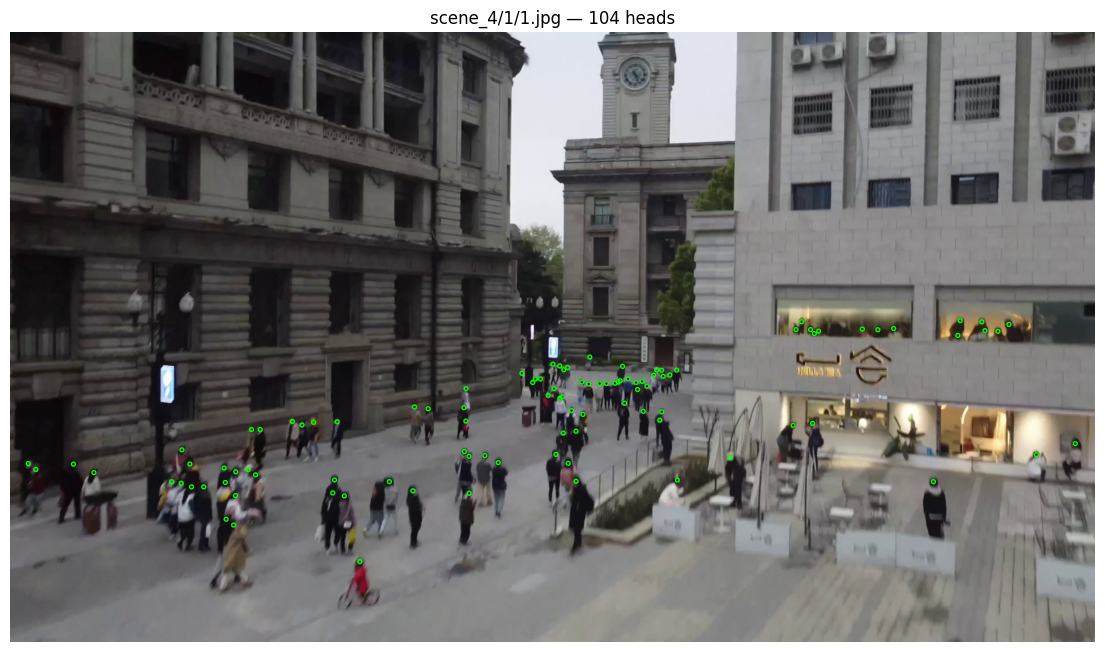

In [6]:
import sys
sys.path.insert(0, str(REPO_DIR))
from crowd_datasets.MDC.mdc import MDCFrameDataset
import matplotlib.pyplot as plt
sample_set = MDCFrameDataset(str(DATASET_ROOT), VAL_SPLIT, train=False, max_samples=1)
image, points, record = sample_set.get_raw_sample(0)
plt.figure(figsize=(14, 8))
plt.imshow(image)
if len(points): plt.scatter(points[:, 0], points[:, 1], s=8, facecolors="none", edgecolors="lime")
plt.title(f"{record.sample_id} — {len(points)} heads")
plt.axis("off"); plt.show()

## 5. Optional legacy diagnostic — model/data check

Skipped by default. The guided `smoke` action is the recommended end-to-end check.


In [7]:
if not RUN_OPTIONAL_SETUP_DIAGNOSTICS:
    print("Skipped optional model/data check. Use ACTION='smoke' for the recommended check.")
else:
    OFFICIAL_WEIGHTS = REPO_DIR / "weights/SHTechA.pth"
    run([sys.executable, "smoke_test.py", "--data_root", DATASET_ROOT,
         "--split_file", TRAIN_SPLIT, "--weights", OFFICIAL_WEIGHTS,
         "--device", "cuda", "--crop_size", "128"])

$ /usr/bin/python3 smoke_test.py --data_root /content/data/MovingDroneCrowd++ --split_file train.txt --weights /content/P2PNet_MDC/weights/SHTechA.pth --device cuda --crop_size 128


CompletedProcess(args=['/usr/bin/python3', 'smoke_test.py', '--data_root', '/content/data/MovingDroneCrowd++', '--split_file', 'train.txt', '--weights', '/content/P2PNet_MDC/weights/SHTechA.pth', '--device', 'cuda', '--crop_size', '128'], returncode=0)

## 6. Optional legacy diagnostic — included-checkpoint inference

Skipped by default; enable only when you specifically want to recheck the bundled checkpoint.


$ /usr/bin/python3 run_test.py --input /content/P2PNet_MDC/vis/demo1.jpg --weight_path /content/P2PNet_MDC/weights/SHTechA.pth --output_dir /content/drive/MyDrive/P2PNet_MDC/runs/p2pnet_mdc_run_001/smoke_inference --device cuda --tile_size 0 --max_size 512


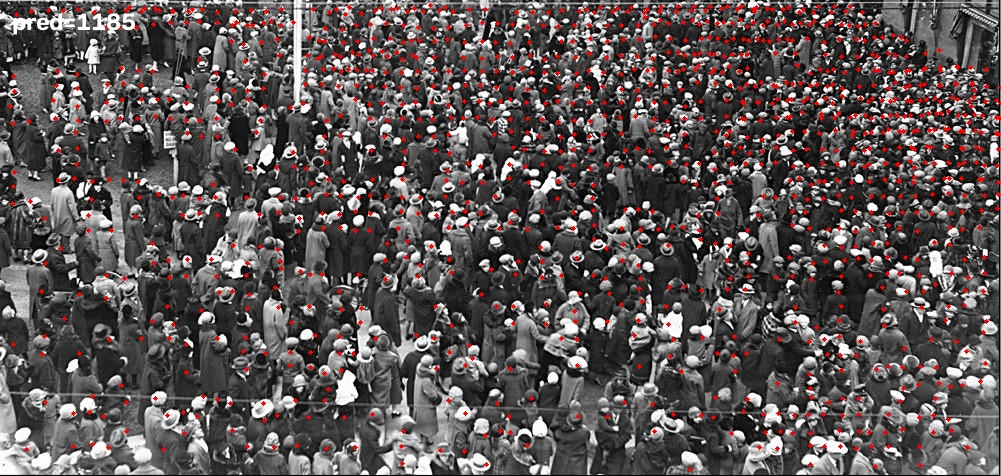

In [8]:
if not RUN_OPTIONAL_SETUP_DIAGNOSTICS:
    print("Skipped optional included-checkpoint inference check. Use ACTION='smoke' for the recommended check.")
else:
    SMOKE_INFERENCE_DIR = RUN_DIR / "smoke_inference"
    run([sys.executable, "run_test.py", "--input", REPO_DIR / "vis/demo1.jpg",
         "--weight_path", OFFICIAL_WEIGHTS, "--output_dir", SMOKE_INFERENCE_DIR,
         "--device", "cuda", "--tile_size", "0", "--max_size", "512"])

    from IPython.display import display
    from PIL import Image
    display(Image.open(next((SMOKE_INFERENCE_DIR / "visualizations").glob("*.jpg"))))

## 7. Optional legacy diagnostic — two-frame evaluation

Skipped by default; this is not an MDC accuracy result.


In [9]:
if not RUN_OPTIONAL_SETUP_DIAGNOSTICS:
    print("Skipped optional two-frame evaluation check. Use ACTION='smoke' for the recommended check.")
else:
    run([sys.executable, "evaluate.py", "--data_root", DATASET_ROOT,
         "--split_file", VAL_SPLIT, "--weight_path", OFFICIAL_WEIGHTS,
         "--output_dir", RUN_DIR / "smoke_evaluation", "--device", "cuda",
         "--max_samples", "2", "--tile_size", "0", "--max_size", "512",
         "--visualize_first", "1"])

$ /usr/bin/python3 evaluate.py --data_root /content/data/MovingDroneCrowd++ --split_file val.txt --weight_path /content/P2PNet_MDC/weights/SHTechA.pth --output_dir /content/drive/MyDrive/P2PNet_MDC/runs/p2pnet_mdc_run_001/smoke_evaluation --device cuda --max_samples 2 --tile_size 0 --max_size 512 --visualize_first 1


CompletedProcess(args=['/usr/bin/python3', 'evaluate.py', '--data_root', '/content/data/MovingDroneCrowd++', '--split_file', 'val.txt', '--weight_path', '/content/P2PNet_MDC/weights/SHTechA.pth', '--output_dir', '/content/drive/MyDrive/P2PNet_MDC/runs/p2pnet_mdc_run_001/smoke_evaluation', '--device', 'cuda', '--max_samples', '2', '--tile_size', '0', '--max_size', '512', '--visualize_first', '1'], returncode=0)

## 8. Optional historical one-batch check

Skipped by default. It uses the older 128-pixel, no-validation diagnostic settings.


In [10]:
if not RUN_OPTIONAL_SETUP_DIAGNOSTICS:
    print("Skipped optional historical one-batch check. Use ACTION='smoke' for the recommended check.")
else:
    run([sys.executable, "train.py", "--dataset_file", "MDC", "--data_root", DATASET_ROOT,
         "--train_split", TRAIN_SPLIT, "--val_split", VAL_SPLIT,
         "--weights", OFFICIAL_WEIGHTS, "--output_dir", "/content/p2pnet_training_smoke",
         "--device", "cuda", "--epochs", "1", "--batch_size", "1",
         "--crop_size", "128", "--num_patches", "1",
         "--max_train_samples", "2", "--max_eval_samples", "1",
         "--max_train_batches", "1", "--eval_freq", "0",
         "--num_workers", "0", "--disable_tensorboard", "--save_every", "0"])

    assert Path("/content/p2pnet_training_smoke/checkpoints/latest.pth").is_file()
    print("Tiny training checkpoint created successfully.")

$ /usr/bin/python3 train.py --dataset_file MDC --data_root /content/data/MovingDroneCrowd++ --train_split train.txt --val_split val.txt --weights /content/P2PNet_MDC/weights/SHTechA.pth --output_dir /content/p2pnet_training_smoke --device cuda --epochs 1 --batch_size 1 --crop_size 128 --num_patches 1 --max_train_samples 2 --max_eval_samples 1 --max_train_batches 1 --eval_freq 0 --num_workers 0 --disable_tensorboard --save_every 0
Tiny training checkpoint created successfully.


## 9. Preflight — understand exactly what will happen

Run this after setup and whenever you change the control panel. It resolves paths, counts
the workload, distinguishes the two frame-stride settings, and states what is automatic.
It does not train or evaluate anything.

- `EVAL_FREQ`: how many training epochs occur between validations.
- `PERIODIC_VAL_FRAME_STRIDE`: validation subset used automatically during training.
- `EVAL_FRAME_STRIDE`: standalone validation/test evaluation selected by `ACTION="evaluate"`.


In [ ]:
from IPython.display import display
import math
import pandas as pd

VALID_ACTIONS = {"inspect", "smoke", "benchmark", "train", "resume", "evaluate", "inference"}
VALID_INITIALIZATIONS = {"shanghaitech", "imagenet", "scratch", "custom"}
VALID_CHECKPOINT_CHOICES = {"best", "latest", "custom"}
SPLIT_FILES = {"train": TRAIN_SPLIT, "val": VAL_SPLIT, "test": TEST_SPLIT}

if ACTION not in VALID_ACTIONS:
    raise ValueError(f"Unknown ACTION={ACTION!r}; choose one of {sorted(VALID_ACTIONS)}")
if INITIALIZATION not in VALID_INITIALIZATIONS:
    raise ValueError(f"Unknown INITIALIZATION={INITIALIZATION!r}")
if RESUME_CHECKPOINT_CHOICE not in VALID_CHECKPOINT_CHOICES:
    raise ValueError(f"Unknown RESUME_CHECKPOINT_CHOICE={RESUME_CHECKPOINT_CHOICE!r}")
if CHECKPOINT_CHOICE not in VALID_CHECKPOINT_CHOICES:
    raise ValueError(f"Unknown CHECKPOINT_CHOICE={CHECKPOINT_CHOICE!r}")
if DATA_SPLIT not in SPLIT_FILES:
    raise ValueError(f"Unknown DATA_SPLIT={DATA_SPLIT!r}")
if not (0 <= THRESHOLD <= 1):
    raise ValueError("THRESHOLD must be between 0 and 1")
if TILE_SIZE > 0 and not (0 <= TILE_OVERLAP < TILE_SIZE):
    raise ValueError("TILE_OVERLAP must be nonnegative and smaller than TILE_SIZE")
if EARLY_STOPPING and EARLY_STOPPING_PATIENCE < 1:
    raise ValueError("EARLY_STOPPING_PATIENCE must be at least 1 when enabled")
if EARLY_STOPPING_MIN_EPOCHS < 0 or EARLY_STOPPING_MIN_DELTA < 0:
    raise ValueError("Early-stopping minimums must be nonnegative")
if BENCHMARK_TRAIN_BATCHES < 1 or BENCHMARK_VAL_FRAMES < 1:
    raise ValueError("Benchmark batch/frame counts must be positive")

def optional_path(value):
    text = str(value).strip()
    return Path(text).expanduser() if text else None

def resolve_checkpoint(choice):
    if choice == "best":
        return RUN_DIR / "checkpoints/best_mae.pth"
    if choice == "latest":
        return RUN_DIR / "checkpoints/latest.pth"
    return optional_path(CUSTOM_CHECKPOINT)

def resolve_initialization_path():
    if INITIALIZATION == "shanghaitech":
        return OFFICIAL_WEIGHTS
    if INITIALIZATION == "custom":
        return optional_path(CUSTOM_INITIALIZATION)
    return None

SELECTED_SPLIT_FILE = SPLIT_FILES[DATA_SPLIT]
if ACTION == "resume":
    SELECTED_CHECKPOINT = resolve_checkpoint(RESUME_CHECKPOINT_CHOICE)
elif ACTION in {"evaluate", "inference"}:
    SELECTED_CHECKPOINT = resolve_checkpoint(CHECKPOINT_CHOICE)
else:
    SELECTED_CHECKPOINT = RUN_DIR / "checkpoints/best_mae.pth"
SELECTED_INITIALIZATION = resolve_initialization_path()

split_counts = {}
if DATASET_ROOT.is_dir():
    from crowd_datasets.MDC.mdc import MDCFrameDataset
    for split_name, split_file in SPLIT_FILES.items():
        split_counts[split_name] = len(MDCFrameDataset(str(DATASET_ROOT), split_file, train=False))

initialization_text = (
    str(SELECTED_INITIALIZATION)
    if INITIALIZATION in {"shanghaitech", "custom"}
    else INITIALIZATION
)
checkpoint_text = str(SELECTED_CHECKPOINT) if SELECTED_CHECKPOINT else "not selected"
checkpoint_status = "exists" if SELECTED_CHECKPOINT and SELECTED_CHECKPOINT.is_file() else "not found yet"
steps_per_epoch = (
    split_counts.get("train", 0) // BATCH_SIZE if BATCH_SIZE > 0 else 0
)
periodic_val_frames = (
    math.ceil(split_counts.get("val", 0) / PERIODIC_VAL_FRAME_STRIDE)
    if PERIODIC_VAL_FRAME_STRIDE > 0 else 0
)

rows = [
    ("ACTION", ACTION),
    ("Run", RUN_NAME),
    ("Persistent output", str(RUN_DIR)),
    ("Initialization", initialization_text),
    ("Selected checkpoint", f"{checkpoint_text} ({checkpoint_status})"),
    ("Selected evaluation split", f"{DATA_SPLIT}: {SELECTED_SPLIT_FILE}"),
    ("Dataset frames", str(split_counts) if split_counts else "dataset not staged"),
    ("Training input", f"{BATCH_SIZE} frame(s) × {NUM_PATCHES} patch(es) × {CROP_SIZE}²"),
    ("Expected optimizer steps/epoch", steps_per_epoch),
    ("Learning rates", f"main={LR:g}; backbone={LR_BACKBONE:g}; weight decay={WEIGHT_DECAY:g}"),
    ("LR schedule", f"multiply both rates by 0.1 after epoch {LR_DROP}"),
    ("Periodic validation", f"every {EVAL_FREQ} epochs; stride={PERIODIC_VAL_FRAME_STRIDE}; about {periodic_val_frames} frames"),
    ("Standalone evaluation", f"stride={EVAL_FRAME_STRIDE}; max samples={MAX_EVAL_SAMPLES or 'all'}"),
    ("Automatic stopping", (
        f"after >= {EARLY_STOPPING_MIN_EPOCHS} epochs and "
        f"{EARLY_STOPPING_PATIENCE} non-improving validation checks"
        if EARLY_STOPPING else "disabled"
    )),
    ("Inference", f"threshold={THRESHOLD:g}; tile={TILE_SIZE}; overlap={TILE_OVERLAP}"),
]
display(pd.DataFrame(rows, columns=["Setting", "Resolved value"]))

print("AUTOMATIC: validation, timing, GPU-memory logging, checkpoints, CSV history, and early stopping.")
print("YOUR DECISIONS: initialization, weight decay, crop/patch strategy, threshold, and final test unlock.")

latest_path = RUN_DIR / "checkpoints/latest.pth"
if ACTION == "train" and latest_path.is_file():
    print("BLOCKED: this run already has latest.pth. Use ACTION='resume' or a new RUN_NAME.")
if ACTION in {"resume", "evaluate", "inference"} and (
    SELECTED_CHECKPOINT is None or not SELECTED_CHECKPOINT.is_file()
):
    print("BLOCKED: the selected checkpoint is empty or does not exist.")
if ACTION == "evaluate" and DATA_SPLIT == "test" and not CONFIRM_FINAL_TEST:
    print("BLOCKED: held-out test requires CONFIRM_FINAL_TEST=True.")
if ACTION == "inspect":
    print("SAFE MODE: inspect performs no training, evaluation, or inference.")
elif ACTION == "benchmark":
    print("NEXT: section 10 will measure these candidates (not accuracy):")
    display(pd.DataFrame(BENCHMARK_CONFIGS))
else:
    print("Preflight complete. If the table is correct, run section 10.")


## 10. Run the selected action

This is the only execution cell for the guided workflow. It prints every command first.
Training automatically validates and can stop itself according to the visible rule above.

If you manually stop training mid-epoch, all earlier completed epochs remain saved. The
partially completed epoch itself is not recorded.


In [ ]:
from datetime import datetime
import json
import math
import subprocess

def initialization_arguments():
    if INITIALIZATION == "shanghaitech":
        if not OFFICIAL_WEIGHTS.is_file():
            raise FileNotFoundError(OFFICIAL_WEIGHTS)
        return ["--weights", OFFICIAL_WEIGHTS]
    if INITIALIZATION == "custom":
        path = resolve_initialization_path()
        if path is None:
            raise ValueError("CUSTOM_INITIALIZATION is empty")
        if not path.is_file():
            raise FileNotFoundError(path)
        return ["--weights", path]
    if INITIALIZATION == "imagenet":
        return []  # train.py defaults to torchvision ImageNet VGG16-BN
    return ["--no-pretrained_backbone"]

def training_command(output_dir, resume_path=None):
    command = [
        sys.executable, "train.py",
        "--dataset_file", "MDC",
        "--data_root", DATASET_ROOT,
        "--train_split", TRAIN_SPLIT,
        "--val_split", VAL_SPLIT,
        "--output_dir", output_dir,
        "--device", "cuda",
        "--epochs", EPOCHS,
        "--lr", LR,
        "--lr_backbone", LR_BACKBONE,
        "--weight_decay", WEIGHT_DECAY,
        "--lr_drop", LR_DROP,
        "--batch_size", BATCH_SIZE,
        "--crop_size", CROP_SIZE,
        "--num_patches", NUM_PATCHES,
        "--scale_min", SCALE_MIN,
        "--scale_max", SCALE_MAX,
        "--flip_probability", FLIP_PROBABILITY,
        "--min_crop_points", MIN_CROP_POINTS,
        "--train_frame_stride", TRAIN_FRAME_STRIDE,
        "--val_frame_stride", PERIODIC_VAL_FRAME_STRIDE,
        "--eval_freq", EVAL_FREQ,
        "--save_every", SAVE_EVERY,
        "--early_stopping_patience", EARLY_STOPPING_PATIENCE if EARLY_STOPPING else 0,
        "--early_stopping_min_epochs", EARLY_STOPPING_MIN_EPOCHS,
        "--early_stopping_min_delta", EARLY_STOPPING_MIN_DELTA,
        "--threshold", THRESHOLD,
        "--tile_size", TILE_SIZE,
        "--tile_overlap", TILE_OVERLAP,
        "--num_workers", NUM_WORKERS,
        "--seed", SEED,
    ]
    if DETERMINISTIC:
        command.append("--deterministic")
    if resume_path is not None:
        command.extend(["--resume", resume_path])
    else:
        command.extend(initialization_arguments())
    return command

def run_unchecked(command):
    command = [str(value) for value in command]
    print("$", shlex.join(command))
    return subprocess.run(command, cwd=REPO_DIR, check=False)

ACTION_OUTPUT_DIR = None

if ACTION == "inspect":
    print("No action executed. Follow the recommended order when ready.")

elif ACTION == "smoke":
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    ACTION_OUTPUT_DIR = Path(f"/content/p2pnet_smoke_{stamp}")
    command = training_command(ACTION_OUTPUT_DIR)
    command.extend([
        "--epochs", "1",
        "--max_train_samples", "2",
        "--max_eval_samples", "1",
        "--max_train_batches", "1",
        "--eval_freq", "1",
        "--val_frame_stride", "1",
        "--save_every", "0",
        "--num_workers", "0",
        "--tile_size", "0",
        "--max_size", "512",
        "--print_freq", "0",
        "--disable_tensorboard",
    ])
    run(command)
    for required in (
        ACTION_OUTPUT_DIR / "checkpoints/latest.pth",
        ACTION_OUTPUT_DIR / "checkpoints/best_mae.pth",
        ACTION_OUTPUT_DIR / "checkpoints/best_checkpoint.json",
        ACTION_OUTPUT_DIR / "training_history.csv",
    ):
        assert required.is_file(), required
    smoke_row = pd.read_csv(ACTION_OUTPUT_DIR / "training_history.csv").iloc[-1]
    display(pd.DataFrame({
        "measurement": [
            "crop / patches", "training batches", "train seconds", "validation seconds",
            "train peak allocated MiB", "validation peak allocated MiB",
        ],
        "value": [
            f"{CROP_SIZE} / {NUM_PATCHES}", int(smoke_row.optimizer_steps),
            smoke_row.train_seconds, smoke_row.validation_seconds,
            smoke_row.train_peak_allocated_mb, smoke_row.validation_peak_allocated_mb,
        ],
    }))
    print("SMOKE PASSED. Timing from one batch/frame is diagnostic only; run benchmark next.")

elif ACTION == "benchmark":
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    runtime_root = Path(f"/content/p2pnet_benchmark_{stamp}")
    ACTION_OUTPUT_DIR = RUN_DIR / "benchmarks" / stamp
    ACTION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    results = []
    for config in BENCHMARK_CONFIGS:
        print("\nBENCHMARK:", config["name"])
        config_output = runtime_root / config["name"]
        command = training_command(config_output)
        command.extend([
            "--epochs", "1",
            "--batch_size", config["batch_size"],
            "--crop_size", config["crop_size"],
            "--num_patches", config["num_patches"],
            "--max_train_batches", BENCHMARK_TRAIN_BATCHES,
            "--max_eval_samples", BENCHMARK_VAL_FRAMES,
            "--eval_freq", "1",
            "--val_frame_stride", "1",
            "--save_every", "0",
            "--print_freq", "0",
            "--disable_tensorboard",
        ])
        completed = run_unchecked(command)
        row = {**config, "status": "passed" if completed.returncode == 0 else f"failed ({completed.returncode})"}
        history_path = config_output / "training_history.csv"
        if completed.returncode == 0 and history_path.is_file():
            measured = pd.read_csv(history_path).iloc[-1]
            run_config = json.loads((config_output / "run_config.json").read_text())
            steps = int(measured.optimizer_steps)
            val_samples = int(measured.validation_samples)
            seconds_per_step = measured.train_seconds / steps
            seconds_per_val = measured.validation_seconds / val_samples
            full_steps = split_counts["train"] // config["batch_size"]
            periodic_frames = math.ceil(split_counts["val"] / PERIODIC_VAL_FRAME_STRIDE)
            estimated_epoch_minutes = seconds_per_step * full_steps / 60
            estimated_periodic_val_minutes = seconds_per_val * periodic_frames / 60
            validation_events = EPOCHS // EVAL_FREQ if EVAL_FREQ > 0 else 0
            estimated_ceiling_hours = (
                estimated_epoch_minutes * EPOCHS
                + estimated_periodic_val_minutes * validation_events
            ) / 60
            row.update({
                "effective_patch_batch": config["batch_size"] * config["num_patches"],
                "seconds_per_train_step": seconds_per_step,
                "patches_per_second": measured.patches_seen / measured.train_seconds,
                "seconds_per_val_frame": seconds_per_val,
                "train_peak_allocated_mb": measured.train_peak_allocated_mb,
                "train_peak_reserved_mb": measured.train_peak_reserved_mb,
                "gpu_total_mb": run_config.get("gpu_total_memory_mb"),
                "estimated_epoch_minutes": estimated_epoch_minutes,
                "estimated_periodic_val_minutes": estimated_periodic_val_minutes,
                "estimated_100_epoch_ceiling_hours": estimated_ceiling_hours,
            })
        results.append(row)

    benchmark = pd.DataFrame(results)
    benchmark.to_csv(ACTION_OUTPUT_DIR / "benchmark_results.csv", index=False)
    (ACTION_OUTPUT_DIR / "benchmark_results.json").write_text(
        json.dumps(results, indent=2, default=str)
    )
    display(benchmark.round(3))
    print("Saved benchmark:", ACTION_OUTPUT_DIR)
    print("IMPORTANT: do not compare the brief benchmark MAE values as model accuracy.")
    print("If both pass, 512×1 favors context; 256×4 favors crop coverage and a larger effective batch.")
    print("Choose explicitly in the control panel, then rerun inspect/smoke before train.")

elif ACTION == "train":
    latest = RUN_DIR / "checkpoints/latest.pth"
    if latest.is_file():
        raise RuntimeError(f"{latest} already exists. Use ACTION='resume' or change RUN_NAME.")
    ACTION_OUTPUT_DIR = RUN_DIR
    run(training_command(RUN_DIR))

elif ACTION == "resume":
    if SELECTED_CHECKPOINT is None:
        raise ValueError("The selected custom checkpoint path is empty")
    if not SELECTED_CHECKPOINT.is_file():
        raise FileNotFoundError(SELECTED_CHECKPOINT)
    ACTION_OUTPUT_DIR = RUN_DIR
    run(training_command(RUN_DIR, resume_path=SELECTED_CHECKPOINT))

elif ACTION == "evaluate":
    if DATA_SPLIT == "test" and not CONFIRM_FINAL_TEST:
        raise RuntimeError(
            "Test evaluation is locked. Freeze checkpoint/threshold first, then set "
            "CONFIRM_FINAL_TEST=True."
        )
    if SELECTED_CHECKPOINT is None:
        raise ValueError("The selected custom checkpoint path is empty")
    if not SELECTED_CHECKPOINT.is_file():
        raise FileNotFoundError(SELECTED_CHECKPOINT)
    threshold_tag = str(THRESHOLD).replace(".", "p")
    ACTION_OUTPUT_DIR = (
        RUN_DIR / "evaluations" /
        f"{DATA_SPLIT}_{SELECTED_CHECKPOINT.stem}_thr{threshold_tag}_stride{EVAL_FRAME_STRIDE}"
    )
    command = [
        sys.executable, "evaluate.py",
        "--data_root", DATASET_ROOT,
        "--split_file", SELECTED_SPLIT_FILE,
        "--weight_path", SELECTED_CHECKPOINT,
        "--output_dir", ACTION_OUTPUT_DIR,
        "--device", "cuda",
        "--threshold", THRESHOLD,
        "--tile_size", TILE_SIZE,
        "--tile_overlap", TILE_OVERLAP,
        "--frame_stride", EVAL_FRAME_STRIDE,
        "--visualize_first", VISUALIZE_FIRST,
    ]
    if MAX_EVAL_SAMPLES > 0:
        command.extend(["--max_samples", MAX_EVAL_SAMPLES])
    run(command)

elif ACTION == "inference":
    if SELECTED_CHECKPOINT is None:
        raise ValueError("The selected custom checkpoint path is empty")
    if not SELECTED_CHECKPOINT.is_file():
        raise FileNotFoundError(SELECTED_CHECKPOINT)
    input_path = Path(INFERENCE_INPUT).expanduser()
    if not input_path.exists():
        raise FileNotFoundError(input_path)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    ACTION_OUTPUT_DIR = RUN_DIR / "inference" / f"{input_path.stem}_{SELECTED_CHECKPOINT.stem}_{stamp}"
    command = [
        sys.executable, "run_test.py",
        "--input", input_path,
        "--weight_path", SELECTED_CHECKPOINT,
        "--output_dir", ACTION_OUTPUT_DIR,
        "--device", "cuda",
        "--threshold", THRESHOLD,
        "--tile_size", TILE_SIZE,
        "--tile_overlap", TILE_OVERLAP,
        "--max_size", INFERENCE_MAX_SIZE,
        "--limit", MAX_INFERENCE_IMAGES,
    ]
    if INFERENCE_RECURSIVE:
        command.append("--recursive")
    if not SAVE_INFERENCE_VISUALIZATIONS:
        command.append("--no_visualizations")
    run(command)

if ACTION_OUTPUT_DIR is not None:
    print("Action output:", ACTION_OUTPUT_DIR)


## 11. Training dashboard — interpret the run

This reads saved files only. It shows accuracy, timing, both learning rates, early-stopping
state and GPU-memory use. Run it after training finishes or after you interrupt/resume.


In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

candidate_dir = globals().get("ACTION_OUTPUT_DIR")
if candidate_dir and (candidate_dir / "training_history.csv").is_file():
    dashboard_dir = candidate_dir
else:
    dashboard_dir = RUN_DIR

history_csv = dashboard_dir / "training_history.csv"
summary_path = dashboard_dir / "training_summary.json"
best_info_path = dashboard_dir / "checkpoints/best_checkpoint.json"

if not history_csv.is_file():
    print("No CSV training history yet:", history_csv)
else:
    history = pd.read_csv(history_csv)
    useful_columns = [
        "epoch_number", "train_loss", "main_lr", "backbone_lr",
        "train_seconds", "validation_samples", "validation_mae", "validation_rmse",
        "validation_seconds", "train_peak_allocated_mb", "new_best",
        "bad_validation_checks", "early_stop_triggered",
    ]
    display(history[[column for column in useful_columns if column in history]].tail(30).round(5))

    validated = history.dropna(subset=["validation_mae"])
    if len(validated):
        best_row = validated.loc[validated["validation_mae"].idxmin()]
        print(
            f"Best periodic validation: epoch {int(best_row.epoch_number)}, "
            f"MAE={best_row.validation_mae:.4f}, RMSE={best_row.validation_rmse:.4f}"
        )

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].plot(history["epoch_number"], history["train_loss"], marker=".")
    axes[0, 0].set(title="Training loss", xlabel="Epoch", ylabel="Loss")
    if len(validated):
        axes[0, 1].plot(validated["epoch_number"], validated["validation_mae"], marker="o", label="MAE")
        axes[0, 1].plot(validated["epoch_number"], validated["validation_rmse"], marker="o", label="RMSE")
        axes[0, 1].legend()
    axes[0, 1].set(title="Periodic validation", xlabel="Epoch", ylabel="Count error")
    axes[1, 0].plot(history["epoch_number"], history["train_seconds"] / 60, label="Training")
    if "validation_seconds" in history:
        axes[1, 0].plot(history["epoch_number"], history["validation_seconds"] / 60, label="Validation")
    axes[1, 0].set(title="Time per epoch", xlabel="Epoch", ylabel="Minutes")
    axes[1, 0].legend()
    axes[1, 1].plot(history["epoch_number"], history["train_peak_allocated_mb"], label="Training")
    if "validation_peak_allocated_mb" in history:
        axes[1, 1].plot(history["epoch_number"], history["validation_peak_allocated_mb"], label="Validation")
    axes[1, 1].set(title="Peak allocated GPU memory", xlabel="Epoch", ylabel="MiB")
    axes[1, 1].legend()
    plt.tight_layout()
    plt.show()

if summary_path.is_file():
    print("Training summary:")
    display(pd.Series(json.loads(summary_path.read_text()), dtype="object"))
if best_info_path.is_file():
    print("Best-checkpoint metadata:")
    display(pd.Series(json.loads(best_info_path.read_text()), dtype="object"))


## 12. Saved evaluation or inference results

This displays the latest aggregate metrics, timing, worst-error frames, or inference table
without rerunning the model. Remember that the square-root metric is RMSE.


In [ ]:
from PIL import Image
from IPython.display import display
import pandas as pd
import json

def newest(paths):
    paths = list(paths)
    return max(paths, key=lambda path: path.stat().st_mtime) if paths else None

preferred = globals().get("ACTION_OUTPUT_DIR")
metrics_path = preferred / "metrics.json" if preferred and (preferred / "metrics.json").is_file() else None
predictions_path = preferred / "predictions.csv" if preferred and (preferred / "predictions.csv").is_file() else None

# Prefer the output of the action that just ran. After a fresh runtime, use whichever
# saved evaluation/inference artifact is newest.
if metrics_path is None and predictions_path is None and RUN_DIR.exists():
    newest_metrics = newest(RUN_DIR.rglob("metrics.json"))
    newest_predictions = newest(RUN_DIR.rglob("predictions.csv"))
    if newest_metrics and newest_predictions:
        if newest_metrics.stat().st_mtime >= newest_predictions.stat().st_mtime:
            metrics_path = newest_metrics
        else:
            predictions_path = newest_predictions
    else:
        metrics_path = newest_metrics
        predictions_path = newest_predictions

result_dir = None
if metrics_path:
    result_dir = metrics_path.parent
    metrics = json.loads(metrics_path.read_text())
    summary_keys = ["samples", "mae", "rmse", "mean_error", "threshold", "split_file", "frame_stride", "wall_seconds", "seconds_per_sample", "samples_per_second"]
    print("Latest evaluation:", result_dir)
    display(pd.Series({key: metrics.get(key) for key in summary_keys}, name="value"))
    per_image = result_dir / "per_image.csv"
    if per_image.is_file():
        frame_results = pd.read_csv(per_image)
        print("Worst absolute-error frames:")
        display(frame_results.nlargest(min(10, len(frame_results)), "absolute_error"))
elif predictions_path:
    result_dir = predictions_path.parent
    predictions = pd.read_csv(predictions_path)
    print("Latest inference:", result_dir)
    display(predictions.head(20))
else:
    print("No saved evaluation or inference results found for this run.")

if result_dir and (result_dir / "visualizations").is_dir():
    images = sorted((result_dir / "visualizations").glob("*.jpg"))[:4]
    for image_path in images:
        print(image_path.name)
        display(Image.open(image_path))


## 13. TensorBoard (optional)

Use this for the detailed training curves stored in the current run directory.


In [ ]:
%load_ext tensorboard
%tensorboard --logdir {RUN_DIR / 'tensorboard'}
